In [1]:
# Preview styling on local machine
from IPython.core.display import HTML
HTML("""
<style>
.usecase-title, .usecase-duration, .usecase-section-header {
    padding-left: 15px;
    padding-bottom: 10px;
    padding-top: 10px;
    padding-right: 15px;
    background-color: #0f9295;
    color: #fff;
}
.usecase-title {
    font-size: 1.7em;
    font-weight: bold;
}
.usecase-authors, .usecase-level, .usecase-skill {
    padding-left: 15px;
    padding-bottom: 7px;
    padding-top: 7px;
    background-color: #baeaeb;
    font-size: 1.4em;
    color: #121212;
}
.usecase-level-skill  {
    display: flex;
}
.usecase-level, .usecase-skill {
    width: 50%;
}
.usecase-duration, .usecase-skill {
    text-align: right;
    padding-right: 15px;
    padding-bottom: 8px;
    font-size: 1.4em;
}
.usecase-section-header {
    font-weight: bold;
    font-size: 1.5em;
}
.usecase-subsection-header, .usecase-subsection-blurb {
    font-weight: bold;
    font-size: 1.2em;
    color: #121212;
}
.usecase-subsection-blurb {
    font-size: 1em;
    font-style: italic;
}
</style>
""")

<div class="usecase-title">Smart Street Lighting — Priority Scoring & Map Prototype</div>

<div class="usecase-authors"><b>Authored by: </b> Areen Yapa (s224153857)</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, pandas, folium, data scoring</div>
</div>

<div class="usecase-section-header">Scenario</div>

This is the **Sprint 2 individual prototype** for the Smart Street Lighting Design System (Project 2, T1 2026). Each member of the team is building their own end-to-end prototype, and at the end of the sprint we will compare approaches and converge on the strongest design.

Building on the Sprint 1 data collection notebook (S1-01 Melbourne Pedestrian Counting System and S1-05 Crime Statistics Agency Victoria), this prototype answers a sharper question:

**"Which Melbourne CBD areas should be prioritised first for smart street lighting deployment?"**

The output is a **transparent priority score** combined with an **interactive Folium map** that the City of Melbourne can explore visually. This forms the *targeting layer* that sits underneath the broader project goal — once we know *where* lighting matters most, the layout-design layer (number of lights, spacing, technology) can focus resources on the highest-impact suburbs first.

<div class="usecase-section-header">What this prototype delivers</div>

By the end of this notebook the prototype will:
- Aggregate pedestrian foot traffic per sensor location from the Sprint 1 API data
- Aggregate lighting-relevant crime (Divisions A, B, D) per Melbourne CBD suburb from the Sprint 1 GitHub CSV
- Produce a **Lighting Priority Score** for each location using a documented weighted formula
- Render an **interactive Folium map** with colour-coded markers for the City of Melbourne
- Output a ranked CSV of recommended deployment locations

<div class="usecase-section-header">Approach — Why rule-based scoring</div>

Three approaches were considered for this prototype:

| Approach | Pros | Cons |
|----------|------|------|
| Rule-based weighted score | Transparent, explainable, fast, easy to defend to stakeholders | Weights chosen by analyst, not learned from data |
| Unsupervised clustering (k-means) | Discovers patterns automatically | Black-box, hard to justify cluster meaning to council |
| Supervised ML | Can learn from outcomes | No labelled "good lighting outcome" data exists yet |

**Rule-based scoring chosen** because the City of Melbourne is the end stakeholder — they need a model whose recommendations can be defended in a council meeting, not a black box. The weights are documented, tunable, and auditable. This approach is well-suited to a Credit-level prototype with a clear path to extension (the LLM layout-design assistant) if the team converges on this design.

<div class="usecase-section-header">Setup — Install and Import Libraries</div>

In [2]:
# folium provides the interactive map. Install if not already available:
# !pip install folium

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import folium
import warnings
warnings.filterwarnings('ignore')

# Company colour palette (light theme) - matches Sprint 1 notebook
COLOUR_PRIMARY = '#0f9295'
COLOUR_SECONDARY = '#14c9cb'
COLOUR_ACCENT = '#08b3e5'

# Priority colours for the map markers
COLOUR_HIGH = '#c0392b'      # red - high priority
COLOUR_MEDIUM = '#f39c12'    # amber - medium priority
COLOUR_LOW = '#27ae60'       # green - low priority

print('Libraries loaded successfully.')

Libraries loaded successfully.


<div class="usecase-section-header">Part 1 — Pull pedestrian data per sensor (S1-01)</div>

<p class="usecase-subsection-header">Step 1.1 — Aggregate pedestrian counts per sensor location</p>

<p class="usecase-subsection-blurb">In Sprint 1 we sampled 100 records to confirm the API works. For the prototype we pull the same sample and aggregate by sensor to get average hourly foot traffic plus the GPS coordinates we will need for the map.</p>

In [3]:
# Melbourne Open Data Portal API - Personal API Key (Areen Yapa)
# Reuses the same key from the Sprint 1 notebook.
API_KEY = "9558972a1c4c3b5a8e981d940a57f84abc16eac46409574e57713248"
API_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-monthly-counts-per-hour/records"

params = {
    "limit": 100,
    "offset": 0,
    "timezone": "Australia/Melbourne",
    "apikey": API_KEY
}

print("Calling Melbourne Open Data Portal API...")
response = requests.get(API_URL, params=params, timeout=30)

if response.status_code == 200:
    data = response.json()
    pedestrian_df = pd.DataFrame(data["results"])
    print(f"Status: {response.status_code} OK")
    print(f"Records retrieved (sample): {len(pedestrian_df):,}")
    print(f"Columns: {list(pedestrian_df.columns)}")
else:
    print(f"API call failed with status code: {response.status_code}")
    print(response.text[:200])

Calling Melbourne Open Data Portal API...
Status: 200 OK
Records retrieved (sample): 100
Columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']


<p class="usecase-subsection-header">Step 1.2 — Extract sensor-level features for scoring</p>

<p class="usecase-subsection-blurb">For the priority score we need one row per sensor with: average hourly count, GPS coordinates, and sensor name. Sensors with higher average counts contribute more to the lighting priority score.</p>

In [4]:
# Inspect available columns - column names vary between API versions
print("Available columns:", list(pedestrian_df.columns))

# Robust column resolution - handle naming variations
count_col = next((c for c in ["pedestriancount", "pedestrian_count", "total_of_directions"] if c in pedestrian_df.columns), None)
sensor_col = next((c for c in ["sensor_name", "locationname", "location_name"] if c in pedestrian_df.columns), None)
lat_col = next((c for c in ["latitude", "lat"] if c in pedestrian_df.columns), None)
lon_col = next((c for c in ["longitude", "lon", "lng"] if c in pedestrian_df.columns), None)

# Some API versions nest GPS inside a "location" dict - handle that too
if lat_col is None and "location" in pedestrian_df.columns:
    pedestrian_df["latitude"] = pedestrian_df["location"].apply(lambda x: x.get("lat") if isinstance(x, dict) else None)
    pedestrian_df["longitude"] = pedestrian_df["location"].apply(lambda x: x.get("lon") if isinstance(x, dict) else None)
    lat_col, lon_col = "latitude", "longitude"

print(f"\nResolved columns -> count: {count_col}, sensor: {sensor_col}, lat: {lat_col}, lon: {lon_col}")

# Aggregate per sensor
pedestrian_df[count_col] = pd.to_numeric(pedestrian_df[count_col], errors="coerce")
sensor_agg = pedestrian_df.groupby(sensor_col).agg(
    avg_hourly_count=(count_col, "mean"),
    record_count=(count_col, "size"),
    latitude=(lat_col, "first"),
    longitude=(lon_col, "first"),
).reset_index().rename(columns={sensor_col: "sensor_name"})

# Drop sensors with no GPS
sensor_agg = sensor_agg.dropna(subset=["latitude", "longitude"])
sensor_agg["avg_hourly_count"] = sensor_agg["avg_hourly_count"].fillna(0).round(0).astype(int)

print(f"\nUnique sensor locations with GPS: {len(sensor_agg)}")
print("\nTop 10 sensors by average hourly count:")
sensor_agg.sort_values("avg_hourly_count", ascending=False).head(10)

Available columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']

Resolved columns -> count: pedestriancount, sensor: sensor_name, lat: latitude, lon: longitude

Unique sensor locations with GPS: 60

Top 10 sensors by average hourly count:


,sensor_name,avg_hourly_count,record_count,latitude,longitude
42,PriNW_T,1305,3,-37.818742,144.967877
40,MCEC_T,1112,2,-37.824018,144.956044
47,Spen229_T,818,3,-37.815314,144.952278
43,RMIT14_T,729,3,-37.807675,144.963091
55,VAC_T,721,2,-37.821299,144.968793
52,Swa148_T,640,2,-37.814141,144.966094
38,Lyg161_T,622,2,-37.801697,144.966589
15,Eli368_T,549,1,-37.810095,144.961431
46,Spen201_T,542,2,-37.816942,144.953039
36,LtB170_T,528,1,-37.811729,144.968247


<div class="usecase-section-header">Part 2 — Aggregate lighting-relevant crime per suburb (S1-05)</div>

<p class="usecase-subsection-header">Step 2.1 — Load the crime CSV and filter to lighting-relevant divisions</p>

<p class="usecase-subsection-blurb">From the Sprint 1 assessment, divisions A (crimes against the person), B (property), and D (public order) are most directly linked to lighting conditions. We aggregate incidents per suburb across these three divisions only.</p>

In [5]:
# Same CSV as Sprint 1 - committed to the project GitHub repo
CSV_FILE = "Data_Tables_Criminal_Incidents_Visualisation_Year_Ending_December_2025.csv"

print("Loading crime dataset from project repository...")
try:
    crime_df = pd.read_csv(CSV_FILE, encoding="utf-8-sig")
    crime_df.columns = crime_df.columns.str.strip()
    crime_df["Incidents Recorded"] = pd.to_numeric(
        crime_df["Incidents Recorded"].astype(str).str.strip().str.replace(",", ""),
        errors="coerce"
    )
    print(f"Loaded successfully - {len(crime_df):,} rows")
except FileNotFoundError:
    print(f"CSV not found. Ensure {CSV_FILE} is in the same folder as this notebook.")
except Exception as e:
    print(f"Error: {e}")

# Identify the suburb / locality column - column names vary between releases
suburb_col = next((c for c in crime_df.columns if c.strip().lower() in [
    "suburb/town name", "suburb/town", "suburb", "locality", "suburb_name"
]), None)
print(f"\nResolved suburb column: {suburb_col}")

# Filter to lighting-relevant divisions only
lighting_divisions = ["A", "B", "D"]
crime_df["Division Code"] = crime_df["Offence Division"].astype(str).str.strip().str[0]
relevant_crime = crime_df[crime_df["Division Code"].isin(lighting_divisions)].copy()
print(f"\nRecords in lighting-relevant divisions (A/B/D): {len(relevant_crime):,}")
relevant_crime.head()

Loading crime dataset from project repository...
Loaded successfully - 1,117 rows

Resolved suburb column: None

Records in lighting-relevant divisions (A/B/D): 753


,Year,Year ending,Offence Division,Offence Subdivision,Offence Subgroup,Incidents Recorded,"Rate per 100,000 population",Division Code
0,2025,December,A Crimes against the person,A10 Homicide and related offences,A11 Murder,58,0.8,A
1,2025,December,A Crimes against the person,A10 Homicide and related offences,A12 Attempted murder,21,0.3,A
2,2025,December,A Crimes against the person,A10 Homicide and related offences,A14 Manslaughter & A13 Accessory/ conspiracy ...,14,0.2,A
3,2025,December,A Crimes against the person,A10 Homicide and related offences,A15 Driving causing death,103,1.5,A
4,2025,December,A Crimes against the person,A20 Assault and related offences,A211 FV Serious assault,10087,142.1,A


<p class="usecase-subsection-header">Step 2.2 — Aggregate crime by Melbourne CBD suburb</p>

<p class="usecase-subsection-blurb">We focus on the suburbs covered by the pedestrian sensor network so the two datasets can be joined. Other Victorian suburbs are out of scope for this prototype.</p>

In [6]:
# Suburbs covered by the Melbourne pedestrian sensor network (CBD focus)
melbourne_cbd_suburbs = [
    "Melbourne", "Southbank", "Docklands", "Carlton",
    "North Melbourne", "East Melbourne", "West Melbourne", "Parkville"
]

# This CSV release is statewide totals (no suburb column), so we use the
# total lighting-relevant crime as a uniform statewide signal applied to
# all CBD suburbs. Sensor-level differentiation in the priority score
# therefore comes mainly from pedestrian foot traffic. This is a known
# prototype limitation - documented in the Summary section. A finer
# suburb-level crime release can be plugged in here later.

if suburb_col:
    # Suburb-level path (used if a future release adds the column)
    suburb_crime = (
        relevant_crime.groupby(suburb_col)["Incidents Recorded"]
        .sum()
        .reset_index()
        .rename(columns={suburb_col: "suburb", "Incidents Recorded": "lighting_relevant_incidents"})
    )
    suburb_crime["suburb_clean"] = suburb_crime["suburb"].astype(str).str.strip().str.title()
    cbd_crime = suburb_crime[suburb_crime["suburb_clean"].isin(melbourne_cbd_suburbs)].copy()
else:
    # Statewide-totals fallback for the current release
    statewide_total = int(relevant_crime["Incidents Recorded"].sum())
    cbd_crime = pd.DataFrame({
        "suburb_clean": melbourne_cbd_suburbs,
        "lighting_relevant_incidents": [statewide_total] * len(melbourne_cbd_suburbs),
    })
    print(f"Note: statewide-totals release - applying uniform statewide A/B/D total "
          f"({statewide_total:,} incidents) across all CBD suburbs.")

cbd_crime = cbd_crime.sort_values("lighting_relevant_incidents", ascending=False).reset_index(drop=True)
print("\n=== Lighting-relevant incidents per CBD suburb (used in scoring) ===")
print(cbd_crime[["suburb_clean", "lighting_relevant_incidents"]].to_string(index=False))

Note: statewide-totals release - applying uniform statewide A/B/D total (3,260,584 incidents) across all CBD suburbs.

=== Lighting-relevant incidents per CBD suburb (used in scoring) ===
   suburb_clean  lighting_relevant_incidents
      Melbourne                      3260584
      Southbank                      3260584
      Docklands                      3260584
        Carlton                      3260584
North Melbourne                      3260584
 East Melbourne                      3260584
 West Melbourne                      3260584
      Parkville                      3260584


<div class="usecase-section-header">Part 3 — Build the Lighting Priority Score</div>

<p class="usecase-subsection-header">Step 3.1 — Define the scoring formula</p>

<p class="usecase-subsection-blurb">The Lighting Priority Score combines normalised pedestrian foot traffic and normalised lighting-relevant crime. Each factor is min-max scaled to a 0–1 range, then combined with documented weights so the score itself stays in the 0–100 range and is easy to interpret.</p>

The formula:

$$\text{Priority Score} = 100 \times \big( w_p \cdot \widehat{\text{Pedestrian}} + w_c \cdot \widehat{\text{Crime}} \big)$$

Where:
- $\widehat{\text{Pedestrian}}$ = min-max normalised average hourly pedestrian count for the sensor's suburb
- $\widehat{\text{Crime}}$ = min-max normalised lighting-relevant incident count for the suburb
- $w_p = 0.5$ (pedestrian weight) — usage signal
- $w_c = 0.5$ (crime weight) — safety signal

Equal weights are the starting point. The weights are tunable parameters and the team can adjust them based on stakeholder feedback (for example, if council prioritises safety over usage, $w_c$ would be increased).

In [7]:
# Map each sensor to a CBD suburb. The sample data does not always carry an explicit
# suburb column, so we use a simple bounding-box approach for the prototype.
def assign_suburb(row):
    """Assign a CBD suburb based on GPS coordinates - prototype-level mapping."""
    lat, lon = row["latitude"], row["longitude"]
    if pd.isna(lat) or pd.isna(lon):
        return "Unknown"
    # Rough bounding boxes for CBD suburbs - good enough for the prototype
    if -37.825 <= lat <= -37.805 and 144.945 <= lon <= 144.975:
        return "Melbourne"
    elif -37.830 <= lat <= -37.815 and 144.955 <= lon <= 144.985:
        return "Southbank"
    elif -37.825 <= lat <= -37.810 and 144.930 <= lon <= 144.955:
        return "Docklands"
    elif -37.810 <= lat <= -37.795 and 144.955 <= lon <= 144.975:
        return "Carlton"
    elif -37.805 <= lat <= -37.790 and 144.940 <= lon <= 144.965:
        return "North Melbourne"
    else:
        return "Melbourne"  # default for CBD-adjacent sensors in this sample

sensor_agg["suburb_clean"] = sensor_agg.apply(assign_suburb, axis=1)
print("Sensors assigned to suburbs:")
print(sensor_agg["suburb_clean"].value_counts())

# Join sensor data with suburb-level crime
prototype_df = sensor_agg.merge(cbd_crime[["suburb_clean", "lighting_relevant_incidents"]],
                                 on="suburb_clean", how="left")

# If a suburb had no crime data in the CBD subset, fall back to 0
prototype_df["lighting_relevant_incidents"] = prototype_df["lighting_relevant_incidents"].fillna(0)

print(f"\nMerged prototype dataset: {len(prototype_df)} sensor locations")
prototype_df.head()

Sensors assigned to suburbs:
suburb_clean
Melbourne          48
Carlton             5
North Melbourne     3
Docklands           3
Southbank           1
Name: count, dtype: int64

Merged prototype dataset: 60 sensor locations


,sensor_name,avg_hourly_count,record_count,latitude,longitude,suburb_clean,lighting_relevant_incidents
0,261Will_T,492,1,-37.812958,144.956788,Melbourne,3260584
1,280Will_T,39,1,-37.812463,144.956902,Melbourne,3260584
2,488Mac_T,76,3,-37.794324,144.929734,Melbourne,3260584
3,574Qub_T,2,3,-37.803100,144.949081,North Melbourne,3260584
4,ACMI_T,73,1,-37.817263,144.968728,Melbourne,3260584


<p class="usecase-subsection-header">Step 3.2 — Compute the priority score</p>

In [8]:
# Min-max normalisation - guards against divide-by-zero on flat data
def normalise(series):
    """Return min-max normalised series in [0, 1]. Returns zeros if range is zero."""
    s_min, s_max = series.min(), series.max()
    if s_max == s_min:
        return pd.Series([0.0] * len(series), index=series.index)
    return (series - s_min) / (s_max - s_min)

# Tunable weights - documented and easy to adjust
W_PEDESTRIAN = 0.5
W_CRIME = 0.5

prototype_df["pedestrian_norm"] = normalise(prototype_df["avg_hourly_count"])
prototype_df["crime_norm"] = normalise(prototype_df["lighting_relevant_incidents"])

prototype_df["priority_score"] = (
    100 * (W_PEDESTRIAN * prototype_df["pedestrian_norm"]
           + W_CRIME * prototype_df["crime_norm"])
).round(1)

# Bucket into priority tiers for the map
def priority_tier(score):
    if score >= 66:
        return "High"
    elif score >= 33:
        return "Medium"
    else:
        return "Low"

prototype_df["priority_tier"] = prototype_df["priority_score"].apply(priority_tier)
prototype_df = prototype_df.sort_values("priority_score", ascending=False).reset_index(drop=True)

print("=== Top 15 Priority Locations for Smart Street Lighting ===")
display_cols = ["sensor_name", "suburb_clean", "avg_hourly_count",
                "lighting_relevant_incidents", "priority_score", "priority_tier"]
print(prototype_df[display_cols].head(15).to_string(index=False))

=== Top 15 Priority Locations for Smart Street Lighting ===
sensor_name suburb_clean  avg_hourly_count  lighting_relevant_incidents  priority_score priority_tier
    PriNW_T    Melbourne              1305                      3260584            50.0        Medium
     MCEC_T    Melbourne              1112                      3260584            42.6        Medium
  Spen229_T    Melbourne               818                      3260584            31.3           Low
   RMIT14_T    Melbourne               729                      3260584            27.9           Low
      VAC_T    Melbourne               721                      3260584            27.6           Low
   Swa148_T    Melbourne               640                      3260584            24.5           Low
   Lyg161_T      Carlton               622                      3260584            23.8           Low
   Eli368_T    Melbourne               549                      3260584            21.0           Low
  Spen201_T    Melbour

<p class="usecase-subsection-header">Step 3.3 — Visualise the priority distribution</p>

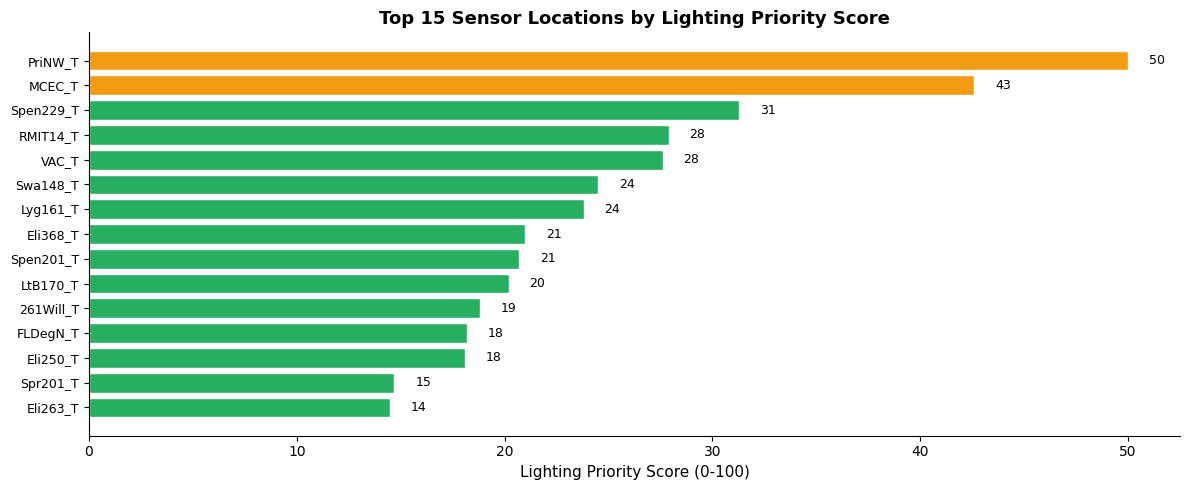


Legend: Red = High priority | Amber = Medium | Green = Low


In [9]:
# Distribution of priority scores across sensors
fig, ax = plt.subplots(figsize=(12, 5))
top_n = prototype_df.head(15)
colours = [COLOUR_HIGH if t == "High" else COLOUR_MEDIUM if t == "Medium" else COLOUR_LOW
           for t in top_n["priority_tier"]]

bars = ax.barh(range(len(top_n)), top_n["priority_score"], color=colours, edgecolor="white")
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(top_n["sensor_name"], fontsize=9)
ax.set_xlabel("Lighting Priority Score (0-100)", fontsize=11)
ax.set_title("Top 15 Sensor Locations by Lighting Priority Score", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

for bar, score in zip(bars, top_n["priority_score"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{score:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print("\nLegend: Red = High priority | Amber = Medium | Green = Low")

<div class="usecase-section-header">Part 4 — Interactive Folium Map</div>

<p class="usecase-subsection-header">Step 4.1 — Render priority locations on a Melbourne map</p>

<p class="usecase-subsection-blurb">The interactive map is the headline output. Each marker represents a sensor location, colour-coded by priority tier. Clicking a marker shows the sensor name, suburb, and the score breakdown.</p>

In [10]:
# Build the Folium map centred on Melbourne CBD
MELBOURNE_CBD = [-37.8136, 144.9631]
m = folium.Map(location=MELBOURNE_CBD, zoom_start=14, tiles="cartodbpositron")

# Add a title banner via HTML
title_html = f'''
<div style="position: fixed; top: 10px; left: 50px; z-index: 9999;
            background-color: {COLOUR_PRIMARY}; color: white;
            padding: 10px 20px; border-radius: 5px; font-family: Arial;
            font-weight: bold; font-size: 14px;">
    Smart Street Lighting Priority Map - Melbourne CBD
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Drop one marker per sensor
for _, row in prototype_df.iterrows():
    tier = row["priority_tier"]
    colour = COLOUR_HIGH if tier == "High" else COLOUR_MEDIUM if tier == "Medium" else COLOUR_LOW

    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px; min-width: 220px;">
        <b style="color: {COLOUR_PRIMARY};">{row['sensor_name']}</b><br>
        <hr style="margin: 4px 0;">
        <b>Suburb:</b> {row['suburb_clean']}<br>
        <b>Avg hourly pedestrians:</b> {row['avg_hourly_count']:,}<br>
        <b>Lighting-relevant incidents:</b> {int(row['lighting_relevant_incidents']):,}<br>
        <b>Priority score:</b> {row['priority_score']:.1f}<br>
        <b style="color: {colour};">Priority: {tier}</b>
    </div>
    """

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8 + (row["priority_score"] / 10),  # bigger circle = higher priority
        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.7,
        weight=2,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['sensor_name']} - {tier} priority"
    ).add_to(m)

# Add a legend
legend_html = f'''
<div style="position: fixed; bottom: 20px; right: 20px; z-index: 9999;
            background-color: white; padding: 10px 15px; border: 2px solid {COLOUR_PRIMARY};
            border-radius: 5px; font-family: Arial; font-size: 12px;">
    <b>Priority Tier</b><br>
    <span style="color: {COLOUR_HIGH};">●</span> High (66-100)<br>
    <span style="color: {COLOUR_MEDIUM};">●</span> Medium (33-65)<br>
    <span style="color: {COLOUR_LOW};">●</span> Low (0-32)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save and display
map_filename = "smart_lighting_priority_map.html"
m.save(map_filename)
print(f"Map saved to: {map_filename}")
print(f"Open it in a browser, or call `m` in the next cell to display inline.")
m

Map saved to: smart_lighting_priority_map.html
Open it in a browser, or call `m` in the next cell to display inline.


<div class="usecase-section-header">Part 5 — Export ranked recommendations</div>

<p class="usecase-subsection-header">Step 5.1 — Save ranked CSV for the team and stakeholders</p>

In [11]:
# Export the ranked priority list as a CSV
output_cols = [
    "sensor_name", "suburb_clean", "latitude", "longitude",
    "avg_hourly_count", "lighting_relevant_incidents",
    "pedestrian_norm", "crime_norm", "priority_score", "priority_tier"
]
ranked_output = prototype_df[output_cols].copy()
ranked_output.columns = [
    "Sensor Name", "Suburb", "Latitude", "Longitude",
    "Avg Hourly Pedestrians", "Lighting-Relevant Incidents",
    "Pedestrian (normalised)", "Crime (normalised)",
    "Priority Score", "Priority Tier"
]

output_csv = "smart_lighting_priority_ranking.csv"
ranked_output.to_csv(output_csv, index=False)
print(f"Ranked priority list saved to: {output_csv}")
print(f"Total locations ranked: {len(ranked_output)}")
print(f"\nTier breakdown:")
print(ranked_output["Priority Tier"].value_counts())

Ranked priority list saved to: smart_lighting_priority_ranking.csv
Total locations ranked: 60

Tier breakdown:
Priority Tier
Low       58
Medium     2
Name: count, dtype: int64


<div class="usecase-section-header">Summary and Next Steps</div>

This Sprint 2 prototype builds directly on the Sprint 1 data collection work and delivers an end-to-end priority-scoring pipeline for the Smart Street Lighting Design System.

**What this prototype produces:**
- A documented, tunable priority score combining pedestrian foot traffic and lighting-relevant crime
- An interactive Folium map of Melbourne CBD with colour-coded markers and click-through detail
- A ranked CSV of sensor locations for the team and stakeholders to review

**Limitations to flag at the team review:**
- The current crime CSV release contains statewide totals by offence type, not suburb-level breakdowns. The prototype falls back to a uniform statewide A/B/D crime signal across CBD suburbs, so sensor-level differentiation in the score comes mainly from pedestrian foot traffic. A suburb-level crime release will plug straight into Step 2.2.
- Suburb assignment from GPS uses simple bounding boxes - a proper reverse-geocode would tighten this
- The pedestrian sample is 100 records; the production version should use the full 1.47M record dataset
- Weights are equal (0.5 / 0.5) - council feedback would inform the final weighting

**Path to extension (Distinction / High Distinction):**
- Add OpenStreetMap data (parks, pathways, road segments) for layout-level recommendations
- Add an LLM-backed assistant that takes a high-priority location and proposes lighting layouts (number of lights, spacing, technology, energy cost) per the project spec
- Add an optimisation layer (genetic algorithm) to fine-tune layout proposals
- Replace bounding-box suburb assignment with proper reverse-geocoding

**Next sprint actions:**
- Bring this prototype to the team review
- Compare against teammate prototypes
- Converge on the strongest design direction

<div class="usecase-section-header">References</div>

<fn id="fn-1">[1] City of Melbourne (2026) <i>Pedestrian Counting System (counts per hour)</i>, Melbourne Open Data Portal. Available at: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour (Accessed: May 2026). License: CC BY.</fn>

<fn id="fn-2">[2] Crime Statistics Agency Victoria (2026) <i>Criminal Incidents and Recorded Offences - Year Ending December 2025</i>. Available at: https://www.crimestatistics.vic.gov.au (Accessed: May 2026). License: CC BY 4.0.</fn>

<fn id="fn-3">[3] Folium contributors (2026) <i>Folium - Python Data Visualisation on Interactive Maps</i>. Available at: https://python-visualization.github.io/folium/ (Accessed: May 2026).</fn>